### Main paper plot 2

X-axis: time taken corresponding to the iteration (log scale)

Y-axis: F(S, Q)

Each curve represents the performance of a method.

In [1]:
import torch
import pickle
import os
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm

In [85]:
from plot_utils import crop_pdf_with_fitz, crop_pdf_with_pdfcrop, crop_pdf_with_pypdf

In [18]:
%load_ext autoreload
%autoreload 1

%aimport plot_utils

In [124]:
legend_labels = [
    r'\textbf{DECoR Early Pooling}',
    r'\textbf{Exact Greedy}',
    r'\textbf{Lazy Greedy}',
    r'\textbf{Stochastic Greedy}',
    r'\textbf{Lazier-than-lazy Greedy}',
    r'\textbf{PLAID}',
    r'\textbf{MUVERA}',
    r'\textbf{WARP}',
    r'\textbf{DECoR Late Pooling}',
]

method_label_map = {
    'submodlib lazy': legend_labels[2],
    'submodlib stochastic 0.5': legend_labels[3],
    'submodlib ltl 0.1': legend_labels[4] + r"\textbf{\epsilon=0.1}",
    'submodlib ltl 0.5': legend_labels[4], # default, so no epsilon mentioned
    'submodlib ltl 0.9': legend_labels[4] + r"\textbf{\epsilon=0.9}",
    'exact greedy': legend_labels[1],
    'WARP iid': legend_labels[7],
    'MUVERA iid': legend_labels[6],
    'ColBERT iid': legend_labels[5],
    'ColBERT angiogram - 1': legend_labels[8],
    # 'ColBERT angiogram - 10',
    # 'ColBERT angiogram - 15',
    # 'ColBERT angiogram - 20',
    'ColBERT bypass - 10': legend_labels[0] + r"\textbf{(top_b=10)}",
    'ColBERT bypass - 1': legend_labels[0],
    'ColBERT bypass - 15': legend_labels[0] + r"\textbf{(top_b=15)}",
 }

methods = ['submodlib lazy', 'submodlib stochastic 0.5', 'submodlib ltl 0.1', 'submodlib ltl 0.5', 'submodlib ltl 0.9', 'exact greedy', 'WARP iid', 'MUVERA iid', 'ColBERT iid', 'ColBERT bypass - 1', 'ColBERT angiogram - 1']

legend_color_map = {
    legend_labels[0]: "black",         # Black (your existing)
    legend_labels[1]: "#2E86AB",       # Ocean Blue - professional and clear
    legend_labels[2]: "#A23B72",       # Deep Rose - distinguishable, elegant
    legend_labels[3]: "#F18F01",       # Amber Orange - warm but not harsh
    legend_labels[4]: "#C73E1D",       # Brick Red - strong contrast
    legend_labels[5]: "#7209B7",       # Royal Purple - rich and distinct
    legend_labels[6]: "#2F9B69",       # Forest Green - natural, easy on eyes
    legend_labels[7]: "#F77F00",        # Burnt Orange - complements the palette
    legend_labels[8]: "#6A4C93"        # Muted Purple - unique but not too bright
}

legend_marker_map = {
    legend_labels[0]: "o",
    legend_labels[1]: "v",
    legend_labels[2]: "v",
    legend_labels[3]: "v",
    legend_labels[4]: "v",
    legend_labels[5]: "^",
    legend_labels[6]: "*",
    legend_labels[7]: "D",
    legend_labels[8]: "o"
}

In [125]:
# Collect data from text files for all datasets
datasets = ['msmarco', 'hotpotqa', 'fever', 'pooled', 'science', 'technology', 'writing']
max_time_vals = {ds: -1 for ds in datasets}

time_map = {ds: {} for ds in datasets}

# The times being stored are single query times for all methods.

# Collect submodlib and exact greedy results
for ds in datasets:
    print(ds)
    # these are comma separated value files with method name and time taken in seconds
    with open(f"./timing_analysis_submodlib_{ds}.txt", "r") as f:
        for idx, line in enumerate(f.readlines()):
            if idx == 0:
                # skip header
                continue
            method, time = line.strip().split(",")
            time_map[ds][method.strip('"')] = float(time)
            if float(time) > max_time_vals[ds]:
                max_time_vals[ds] = float(time)

    # Collect all other results
    with open(f"./timing_analysis_{ds}.txt", "r") as f:
        for idx, line in enumerate(f.readlines()):
            if idx == 0:
                # skip header
                continue
            method, time = line.strip().split(",")
            # since these methods were run for 100 queries each, we divide the time by 100 to get time per query
            time_map[ds][method.strip('"')] = float(time) / 100
            if float(time) / 100 > max_time_vals[ds]:
                max_time_vals[ds] = float(time) / 100

msmarco
hotpotqa
fever
pooled
science
technology
writing


In [126]:
max_time_vals

{'msmarco': 1526.22,
 'hotpotqa': 938.81,
 'fever': 974.79,
 'pooled': 572.39,
 'science': 400.16,
 'technology': 264.27,
 'writing': 208.34}

In [127]:
# Load score data
score_map = {ds: {} for ds in datasets}

for ds in datasets:
    for method in methods:
        inds, scores = plot_utils.get_score_data(ds, method, k=10)
        score_map[ds][method] = scores.mean(dim=0).numpy()

Method is submodlib lazy, loading from /mnt/nas/pritish/DGX/CMUVERA_IR_ref/pickles/results/greedy_submodlib_LazyGreedy_k10_msmarco_bf_k10_submodlib_no_stop.pkl
File not found: greedy_submodlib_LazyGreedy_k10_msmarco_bf_k10_submodlib_no_stop.pkl
submodlib lazy + msmarco does not have k=10 data, defaulting to k=15
Method is submodlib stochastic 0.5, loading from /mnt/nas/pritish/DGX/CMUVERA_IR_ref/pickles/results/greedy_submodlib_StochasticGreedy_k10_msmarco_bf_k10_submodlib_no_stop_eps0.5.pkl
Method is submodlib ltl 0.1, loading from /mnt/nas/pritish/DGX/CMUVERA_IR_ref/pickles/results/greedy_submodlib_LazierThanLazyGreedy_k10_msmarco_bf_k10_submodlib_no_stop.pkl
File not found: greedy_submodlib_LazierThanLazyGreedy_k10_msmarco_bf_k10_submodlib_no_stop.pkl
submodlib ltl 0.1 + msmarco does not have k=10 data, defaulting to k=15
Method is submodlib ltl 0.5, loading from /mnt/nas/pritish/DGX/CMUVERA_IR_ref/pickles/results/greedy_submodlib_LazierThanLazyGreedy_k10_msmarco_bf_k10_submodlib_no

In [111]:
def plot_paper(dataset_name, desired_methods, y_label=True):
    plt.clf()
    fig, ax = plt.subplots(figsize=(8, 6))
    markersize = 10

    plt.rcParams.update({
        'text.usetex': True,
        'text.latex.preamble': r'\usepackage{amsmath}',
        'font.family': 'serif',
        'figure.dpi': 300,
        'lines.markersize': markersize
    })

    for method in desired_methods:
        query_time = time_map[dataset_name][method]
        scores = score_map[dataset_name][method].tolist()
        print(f"Method: {method}, Time: {query_time}, Score: {scores}")
        ax.plot(
            [query_time * i for i in range(1, len(scores) + 1)],
            scores,
            label=method_label_map[method],
            color=legend_color_map[method_label_map[method]],
            marker=legend_marker_map[method_label_map[method]],
            linewidth=2,
            markersize=10,
        )

    # ax.set_title(f'{dataset_name}: F(S) vs K', fontsize=20)
    ax.set_xlabel(r'$\textbf{t}\rightarrow$', fontsize=36)      # Increased axis label size
    if y_label:
        ax.set_ylabel(r'$\textbf{Avg F(S, Q)}\rightarrow$', fontsize=36) # Increased axis label size

    # Xticks logscale
    ax.set_xscale('log')
    # Explicitly set tick label sizes
    ax.tick_params(axis='x', labelsize=40)  # Smaller X-axis tick labels
    ax.tick_params(axis='y', labelsize=40)  # Smaller Y-axis tick labels
    # ax.legend(fontsize=12)
    ax.grid(True)

    plt.tight_layout()
    plt.savefig(f'./notebooks/plots/{dataset_name.lower()}_plot2.pdf')
    plt.show()

In [93]:
def plot_legend_only(desired_methods, filename, ncol=3, auto_crop=True):
    # Create a figure for legend only
    fig, ax = plt.subplots(figsize=(8, 6))
    
    for method in desired_methods:
        ax.plot(
            [], [],
            label=method_label_map[method],
            color=legend_color_map[method_label_map[method]],
            marker=legend_marker_map[method_label_map[method]],
            linewidth=2,
            markersize=10,
        )

    # Hide the plot area
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # Create legend
    legend = ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.1),
        ncol=ncol,
        fontsize=14,
        frameon=False
    )

    # Save the figure
    output_path = f'./notebooks/plots/{filename}.pdf'
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0.1, dpi=300)
    plt.show()
    
    # Auto-crop the PDF if requested
    if auto_crop:
        # Try methods in order of preference
        cropped_path = crop_pdf_with_pdfcrop(output_path)
        if cropped_path is None:
            cropped_path = crop_pdf_with_fitz(output_path)
        if cropped_path is None:
            cropped_path = crop_pdf_with_pypdf(output_path)
        
        if cropped_path:
            # Replace original with cropped version
            os.rename(cropped_path, output_path)
            print(f"PDF automatically cropped: {output_path}")
        else:
            print("Auto-cropping failed, using matplotlib's bbox_inches='tight' only")

In [121]:
dms = ['ColBERT bypass - 1', 'ColBERT angiogram - 1', 'submodlib ltl 0.5', 'exact greedy', 'MUVERA iid', 'submodlib lazy', 'WARP iid', 'submodlib stochastic 0.5', 'ColBERT iid']

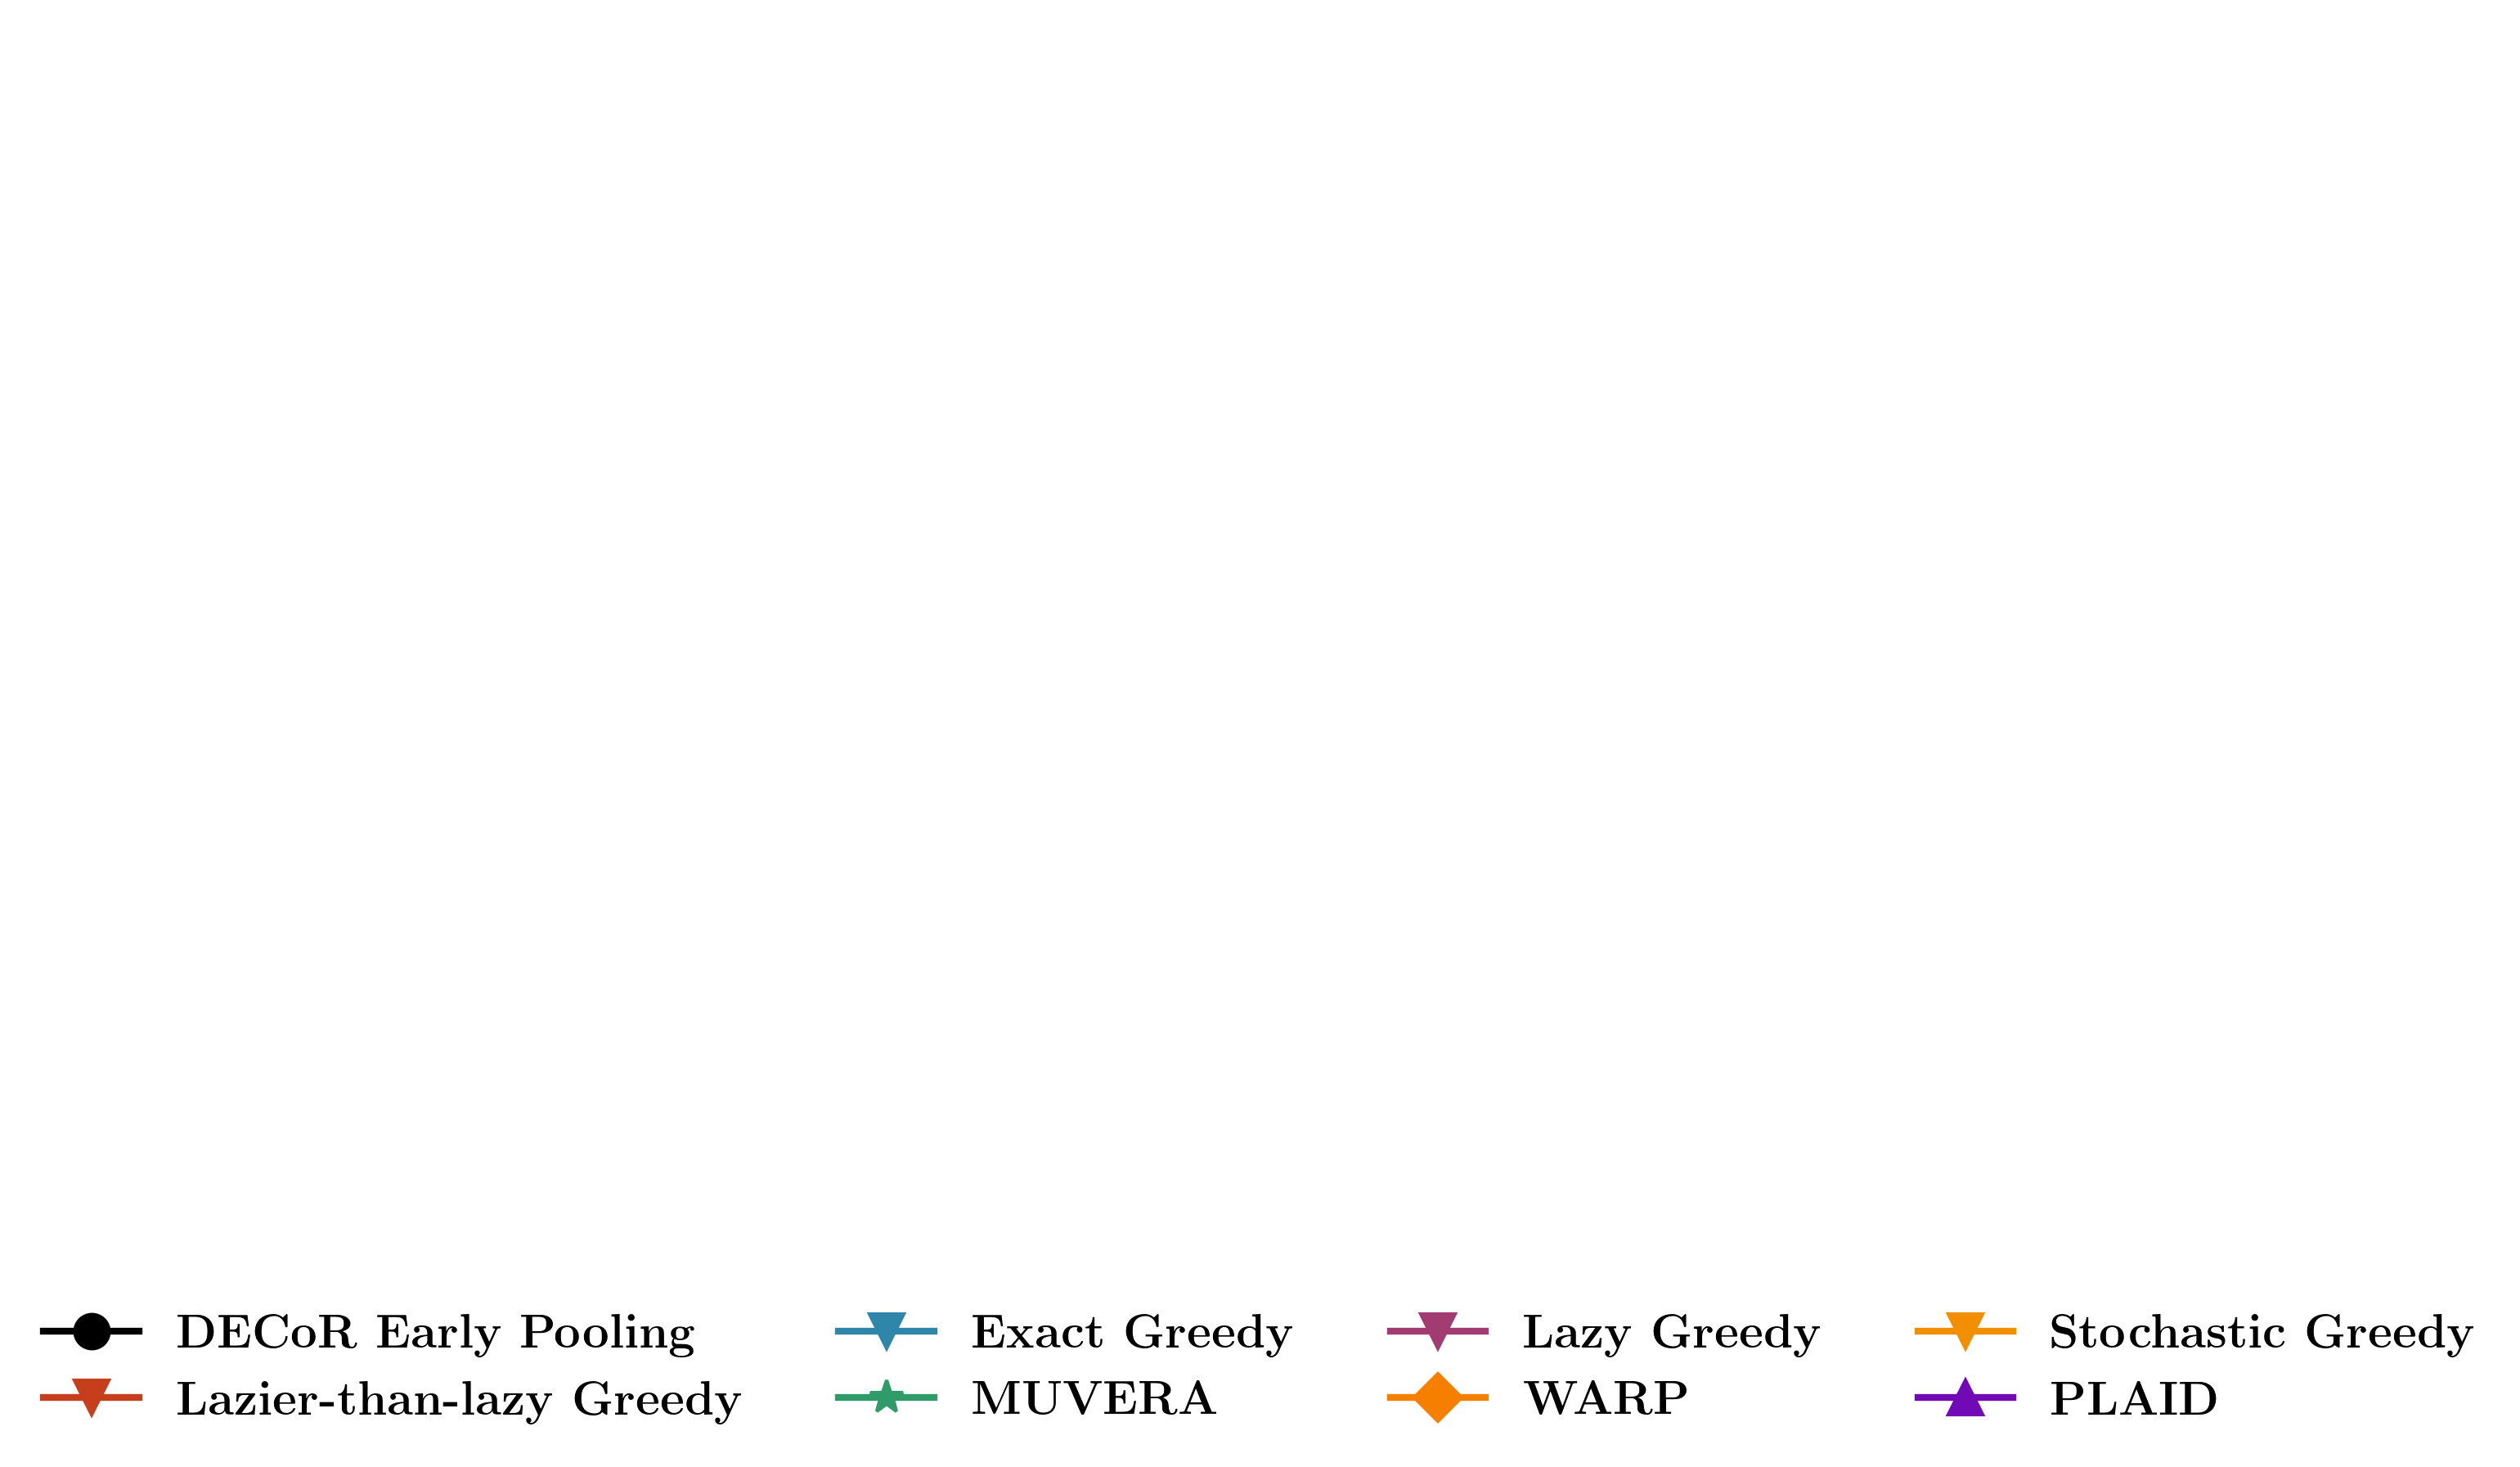

Successfully cropped ./notebooks/plots/plot2_legend.pdf -> ./notebooks/plots/plot2_legend_cropped.pdf
PDF automatically cropped: ./notebooks/plots/plot2_legend.pdf


In [95]:
plot_legend_only(dms, "plot2_legend", ncol=4)

Method: ColBERT bypass - 1, Time: 13.218, Score: [26.960464477539062, 27.947057723999023, 28.177478790283203, 28.188182830810547, 28.18868637084961, 28.18868637084961, 28.18868637084961, 28.18868637084961, 28.18868637084961, 28.18868637084961, 28.18868637084961, 28.18868637084961, 28.18868637084961, 28.18868637084961, 28.18868637084961]
Method: ColBERT angiogram - 1, Time: 11.513900000000001, Score: [26.919031143188477, 27.718585968017578, 27.7979793548584, 27.7979793548584, 27.7979793548584, 27.7979793548584, 27.7979793548584, 27.7979793548584, 27.7979793548584, 27.7979793548584]
Method: submodlib ltl 0.5, Time: 1497.26, Score: [23.7947940826416, 26.575794219970703, 27.765640258789062, 28.078922271728516, 28.15785789489746, 28.221317291259766, 28.2457275390625, 28.375690460205078, 28.416980743408203, 28.4343318939209, 28.452539443969727, 28.486276626586914, 28.489849090576172, 28.527721405029297, 28.544885635375977]
Method: exact greedy, Time: 1370.77, Score: [26.999507904052734, 28.1

<Figure size 1920x1440 with 0 Axes>

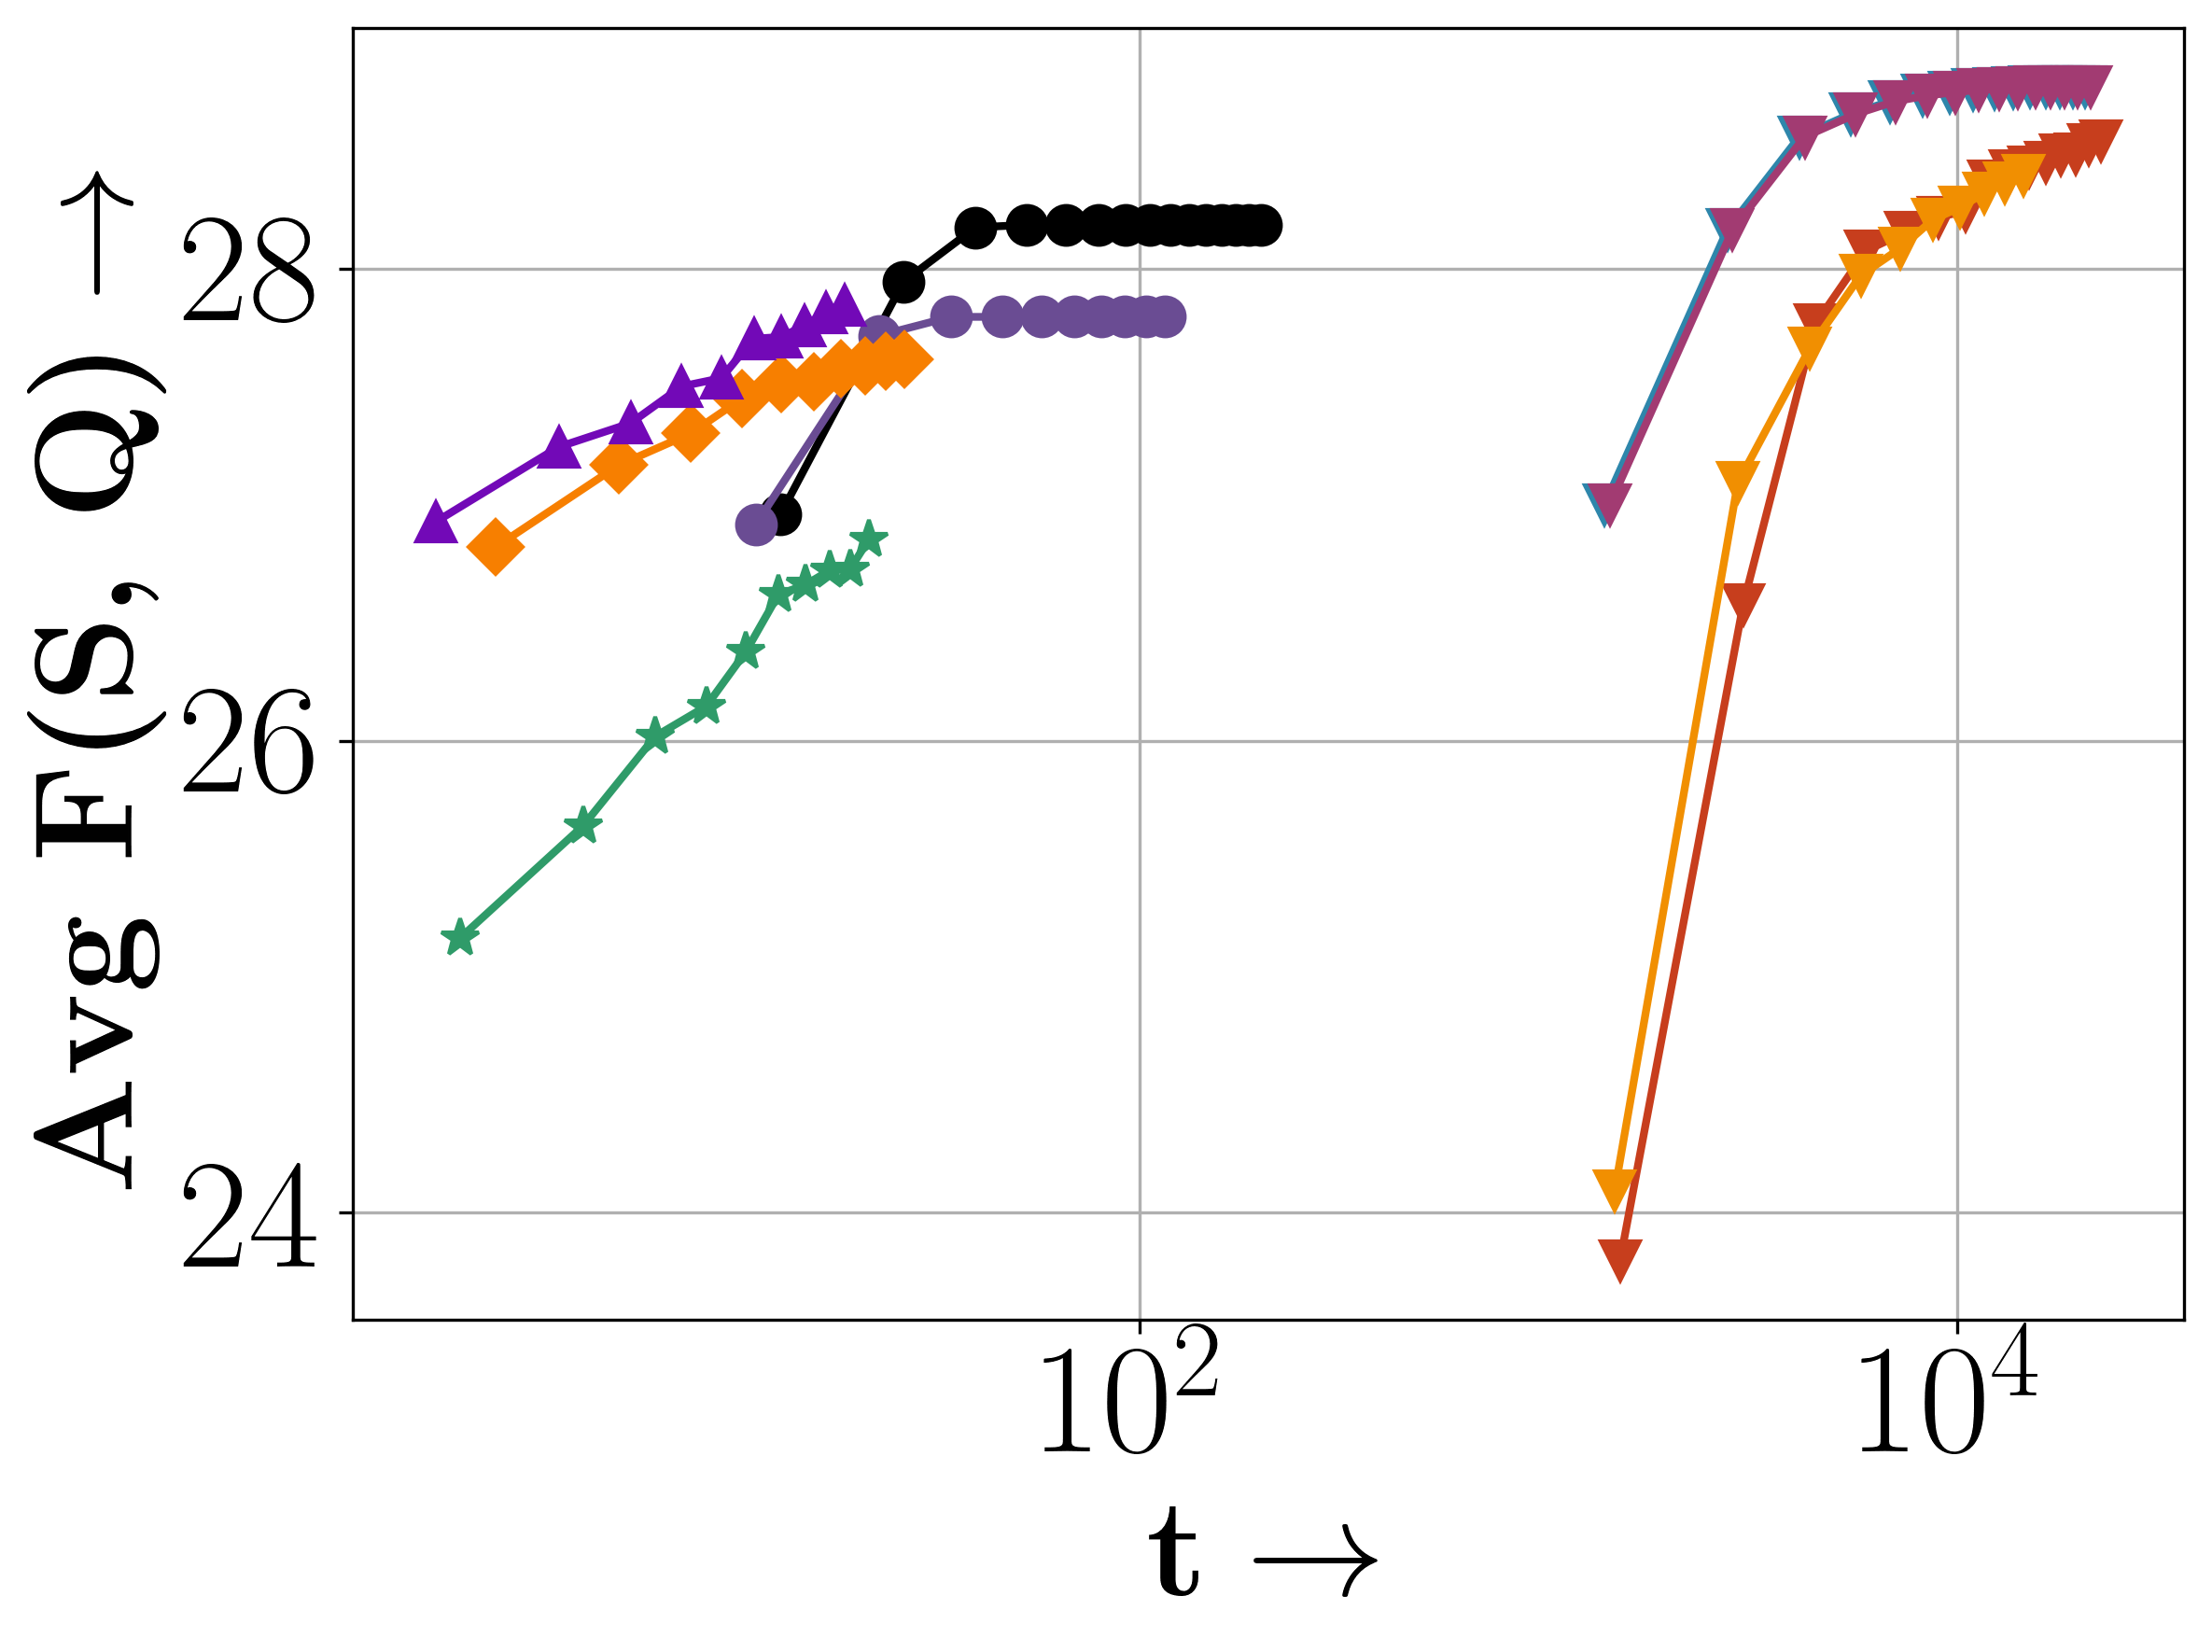

In [128]:
plot_paper("msmarco", dms, y_label=True)

Method: ColBERT bypass - 1, Time: 9.2684, Score: [22.817962646484375, 25.40886116027832, 26.09574317932129, 26.38235855102539, 26.50018310546875, 26.58517074584961, 26.62055015563965, 26.63791275024414, 26.65656089782715, 26.67129135131836, 26.67129135131836, 26.67129135131836, 26.67129135131836, 26.67129135131836, 26.67129135131836]
Method: ColBERT angiogram - 1, Time: 9.3725, Score: [23.38702964782715, 25.189964294433594, 25.63450050354004, 25.78422737121582, 25.83849334716797, 25.859886169433594, 25.867841720581055, 25.871051788330078, 25.872304916381836, 25.872739791870117]
Method: submodlib ltl 0.5, Time: 974.79, Score: [18.498432159423828, 22.86033821105957, 24.766708374023438, 25.3597469329834, 25.69097328186035, 26.063161849975586, 26.269790649414062, 26.395029067993164, 26.443674087524414, 26.519495010375977, 26.57779884338379, 26.610591888427734, 26.657108306884766, 26.712203979492188, 26.745929718017578]
Method: exact greedy, Time: 837.33, Score: [22.88319969177246, 25.47029

<Figure size 1920x1440 with 0 Axes>

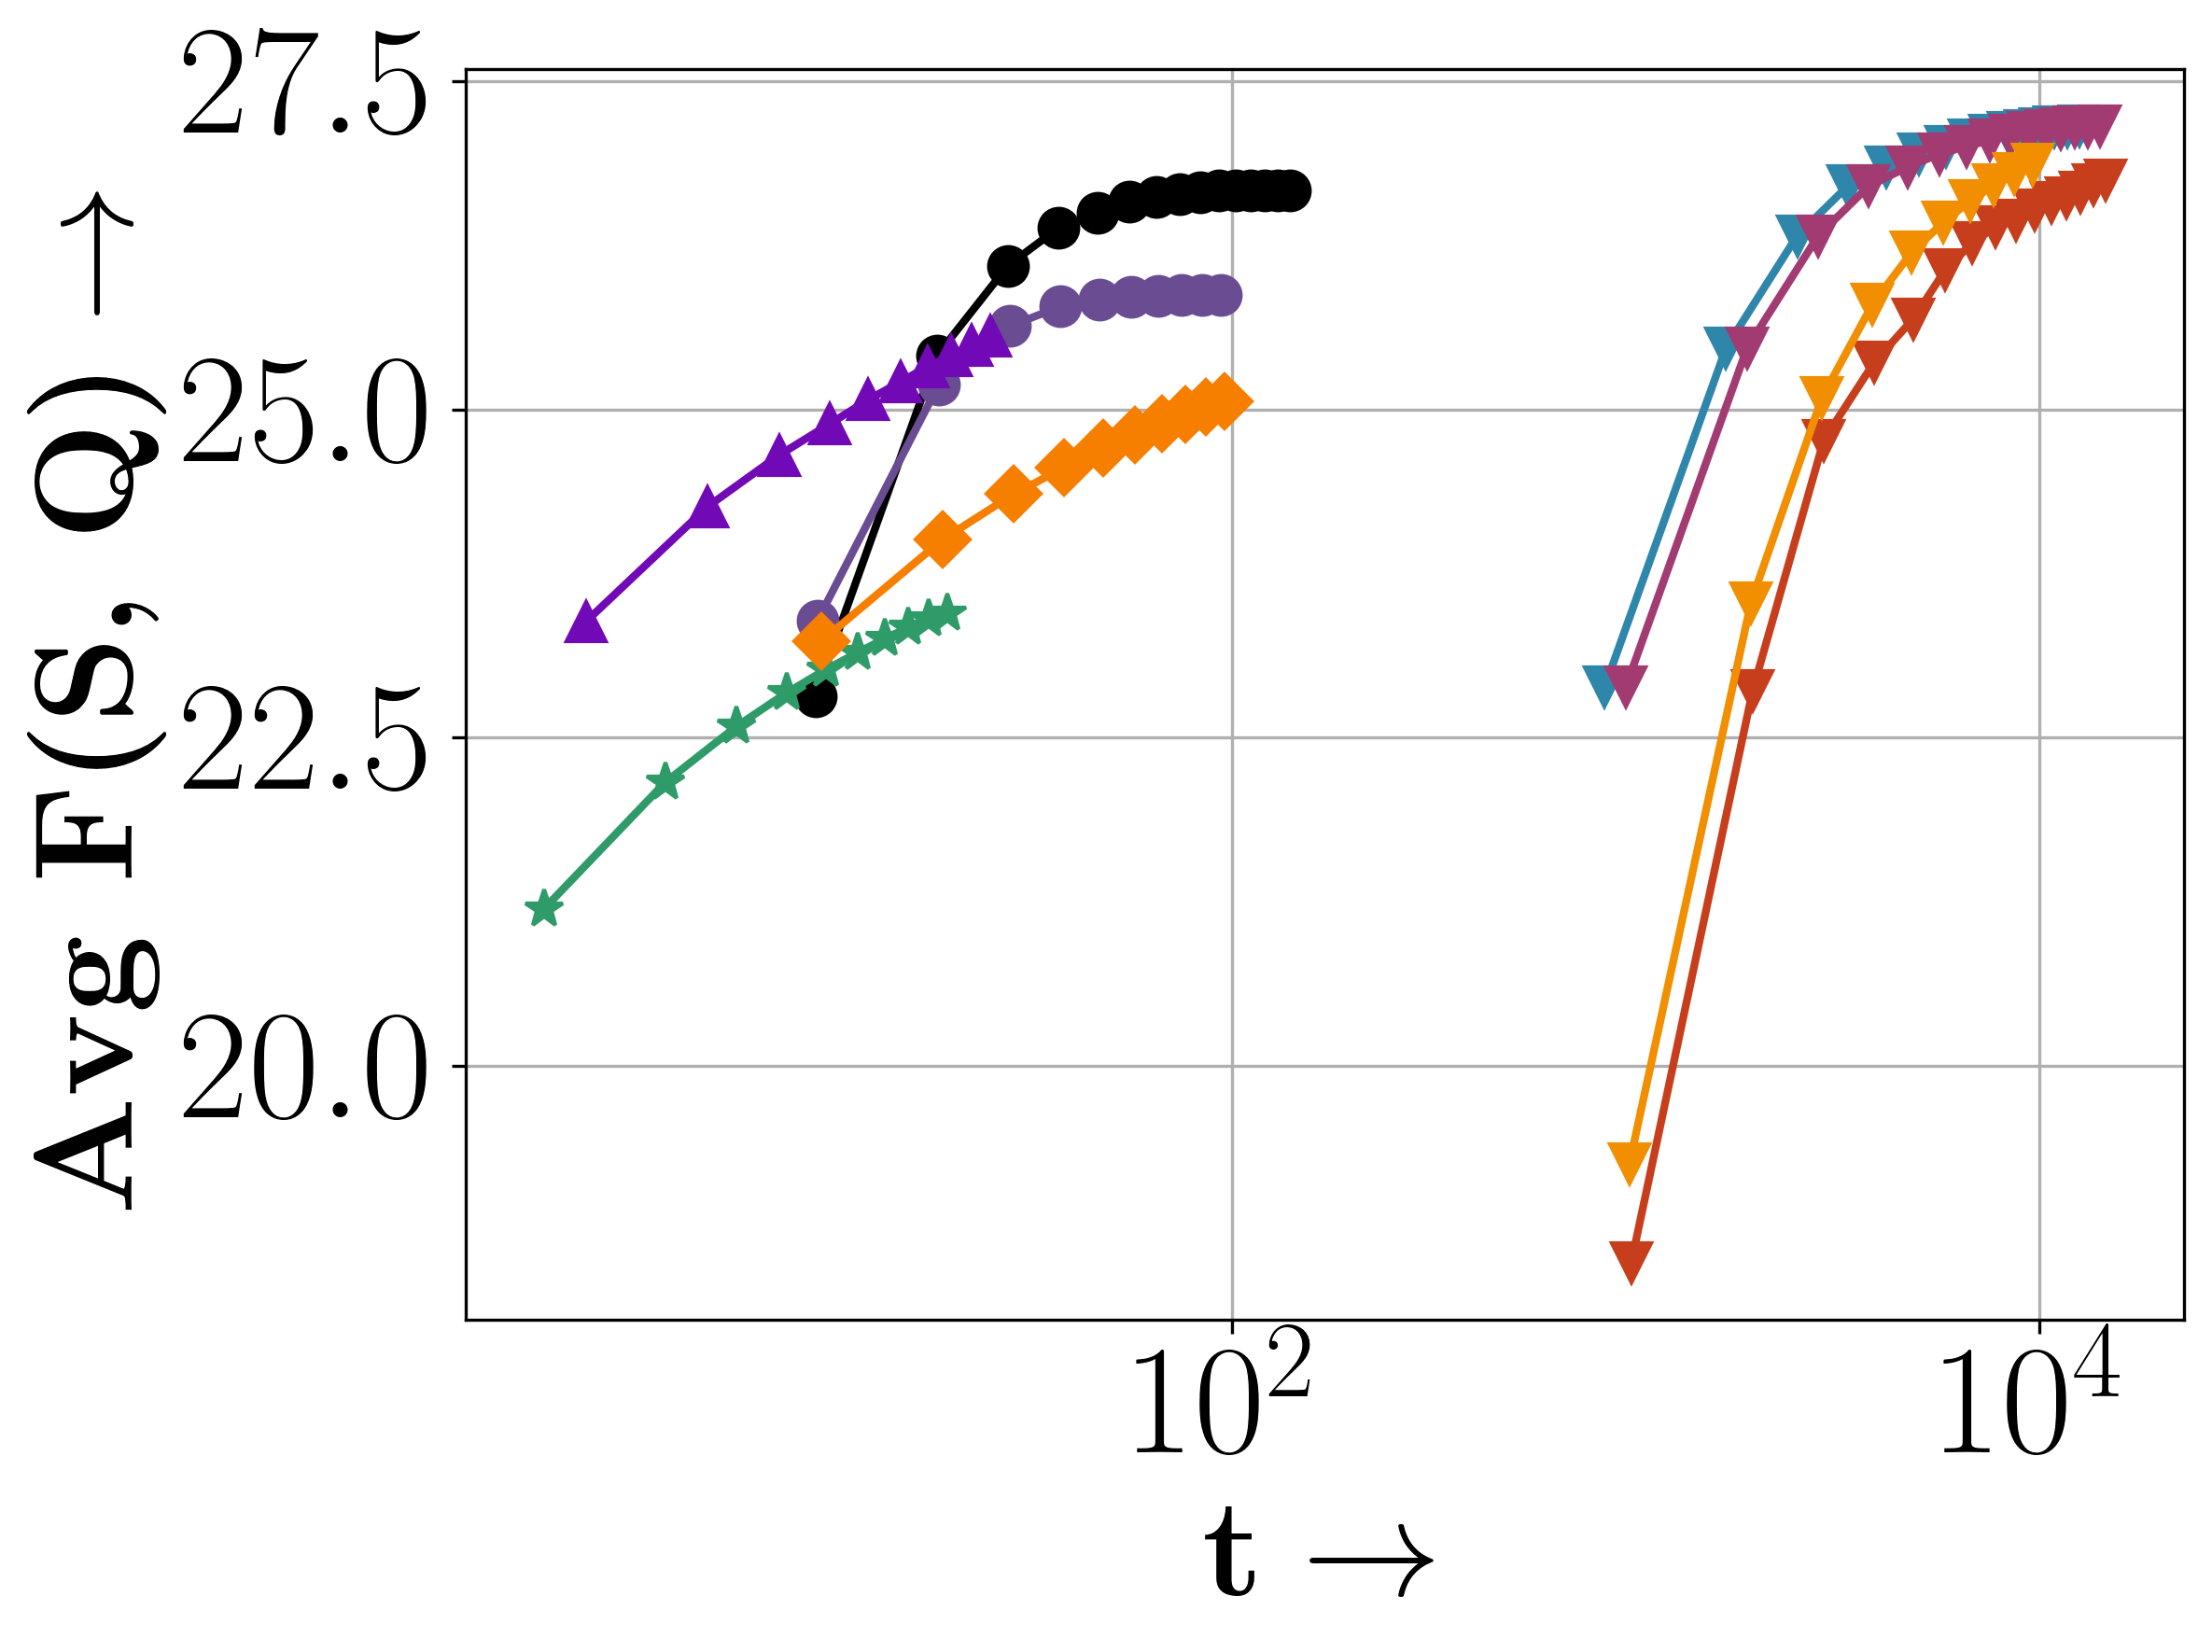

In [129]:
plot_paper("fever", dms, y_label=True)

Method: ColBERT bypass - 1, Time: 8.071900000000001, Score: [20.43692398071289, 24.376346588134766, 25.383129119873047, 25.710424423217773, 25.803348541259766, 25.84365463256836, 25.865947723388672, 25.882720947265625, 25.8968448638916, 25.8968448638916, 25.8968448638916, 25.8968448638916, 25.8968448638916, 25.8968448638916, 25.8968448638916]
Method: submodlib ltl 0.5, Time: 890.42, Score: [16.168643951416016, 20.2138614654541, 22.372587203979492, 23.634103775024414, 24.266658782958984, 24.585697174072266, 24.834453582763672, 25.127222061157227, 25.29376983642578, 25.453758239746094, 25.553804397583008, 25.683979034423828, 25.748571395874023, 25.811899185180664, 25.85445785522461]
Method: exact greedy, Time: 938.81, Score: [20.43692398071289, 24.376773834228516, 25.42472267150879, 25.821468353271484, 25.982715606689453, 26.09726905822754, 26.1788330078125, 26.23697853088379, 26.281600952148438, 26.31622314453125, 26.343170166015625, 26.36447525024414, 26.383249282836914, 26.39893722534

<Figure size 1920x1440 with 0 Axes>

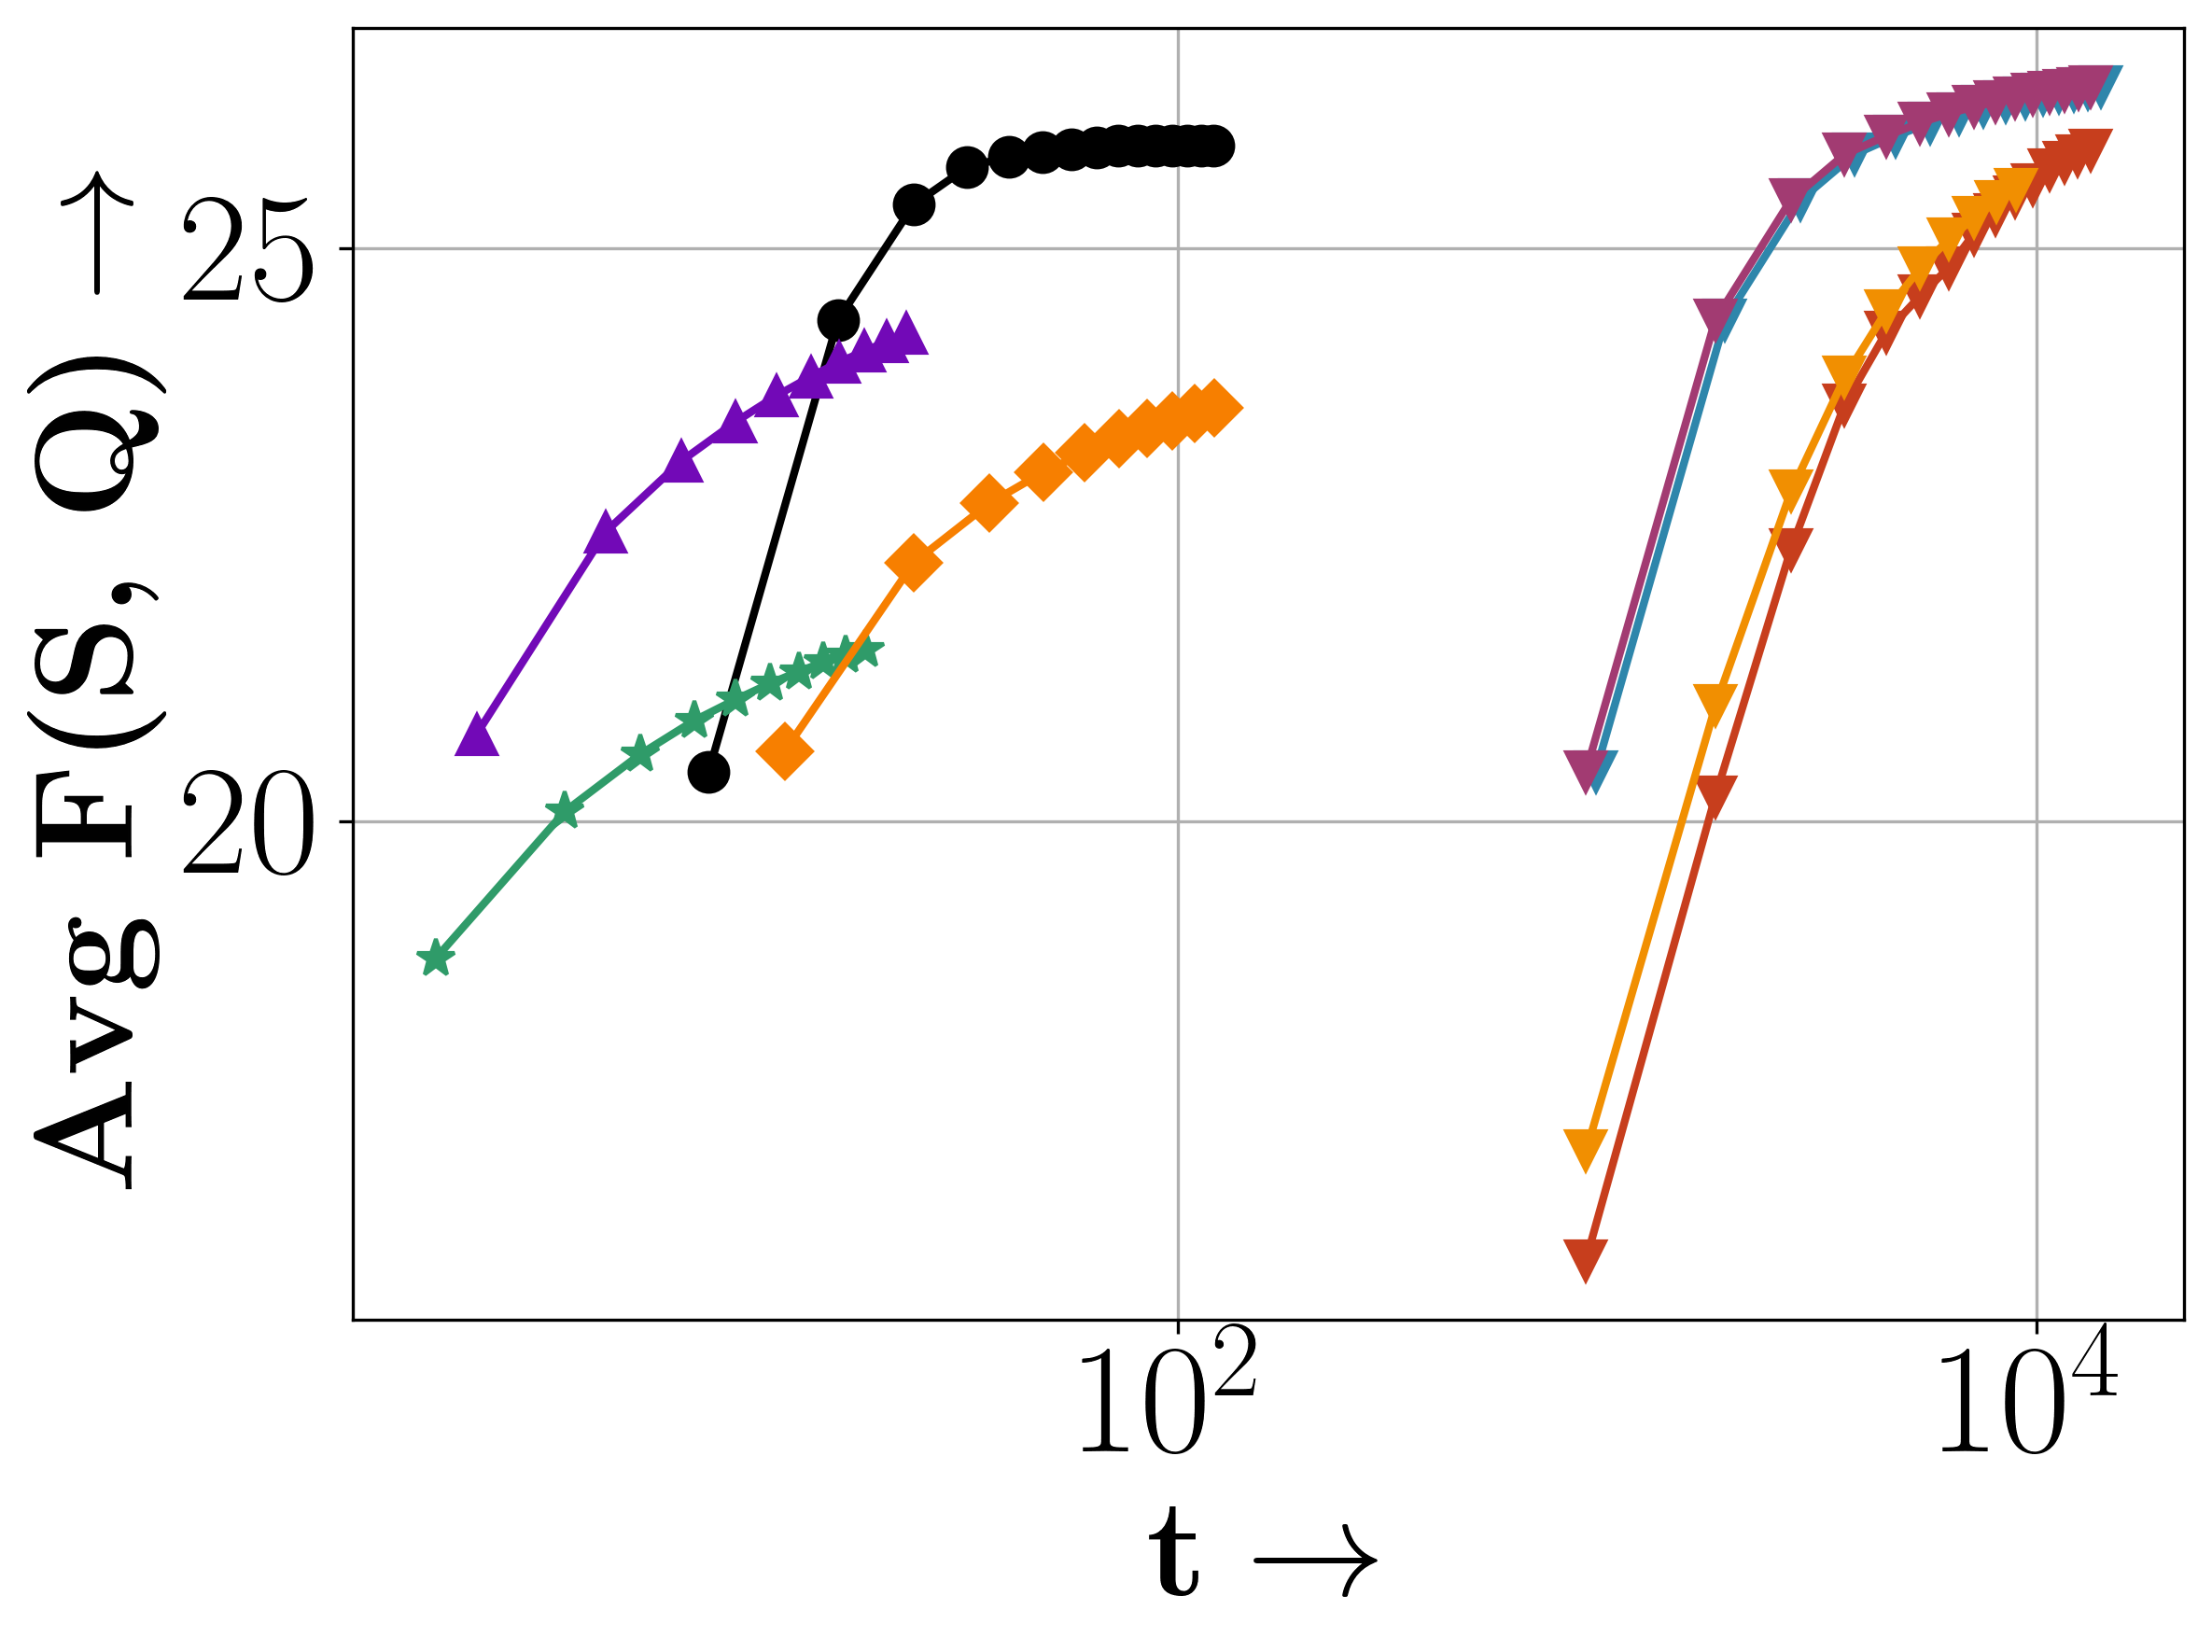

In [114]:
plot_paper("hotpotqa", dms, y_label=True)

Method: ColBERT bypass - 1, Time: 6.630199999999999, Score: [22.179214477539062, 24.403987884521484, 25.078563690185547, 25.35371971130371, 25.482057571411133, 25.54684829711914, 25.582185745239258, 25.60114288330078, 25.61178970336914, 25.617544174194336]
Method: submodlib ltl 0.5, Time: 563.62, Score: [18.98543930053711, 22.606821060180664, 23.973861694335938, 24.644834518432617, 25.035968780517578, 25.287641525268555, 25.464197158813477, 25.592144012451172, 25.693199157714844, 25.774017333984375]
Method: exact greedy, Time: 557.99, Score: [22.222328186035156, 24.553874969482422, 25.340688705444336, 25.710542678833008, 25.91344451904297, 26.035846710205078, 26.114322662353516, 26.166994094848633, 26.20359992980957, 26.229698181152344]
Method: MUVERA iid, Time: 44.8615, Score: [19.141923904418945, 20.433927536010742, 21.021453857421875, 21.351715087890625, 21.56709098815918, 21.7158260345459, 21.817886352539062, 21.896629333496094, 21.949634552001953, 21.98836326599121]
Method: submod

<Figure size 1920x1440 with 0 Axes>

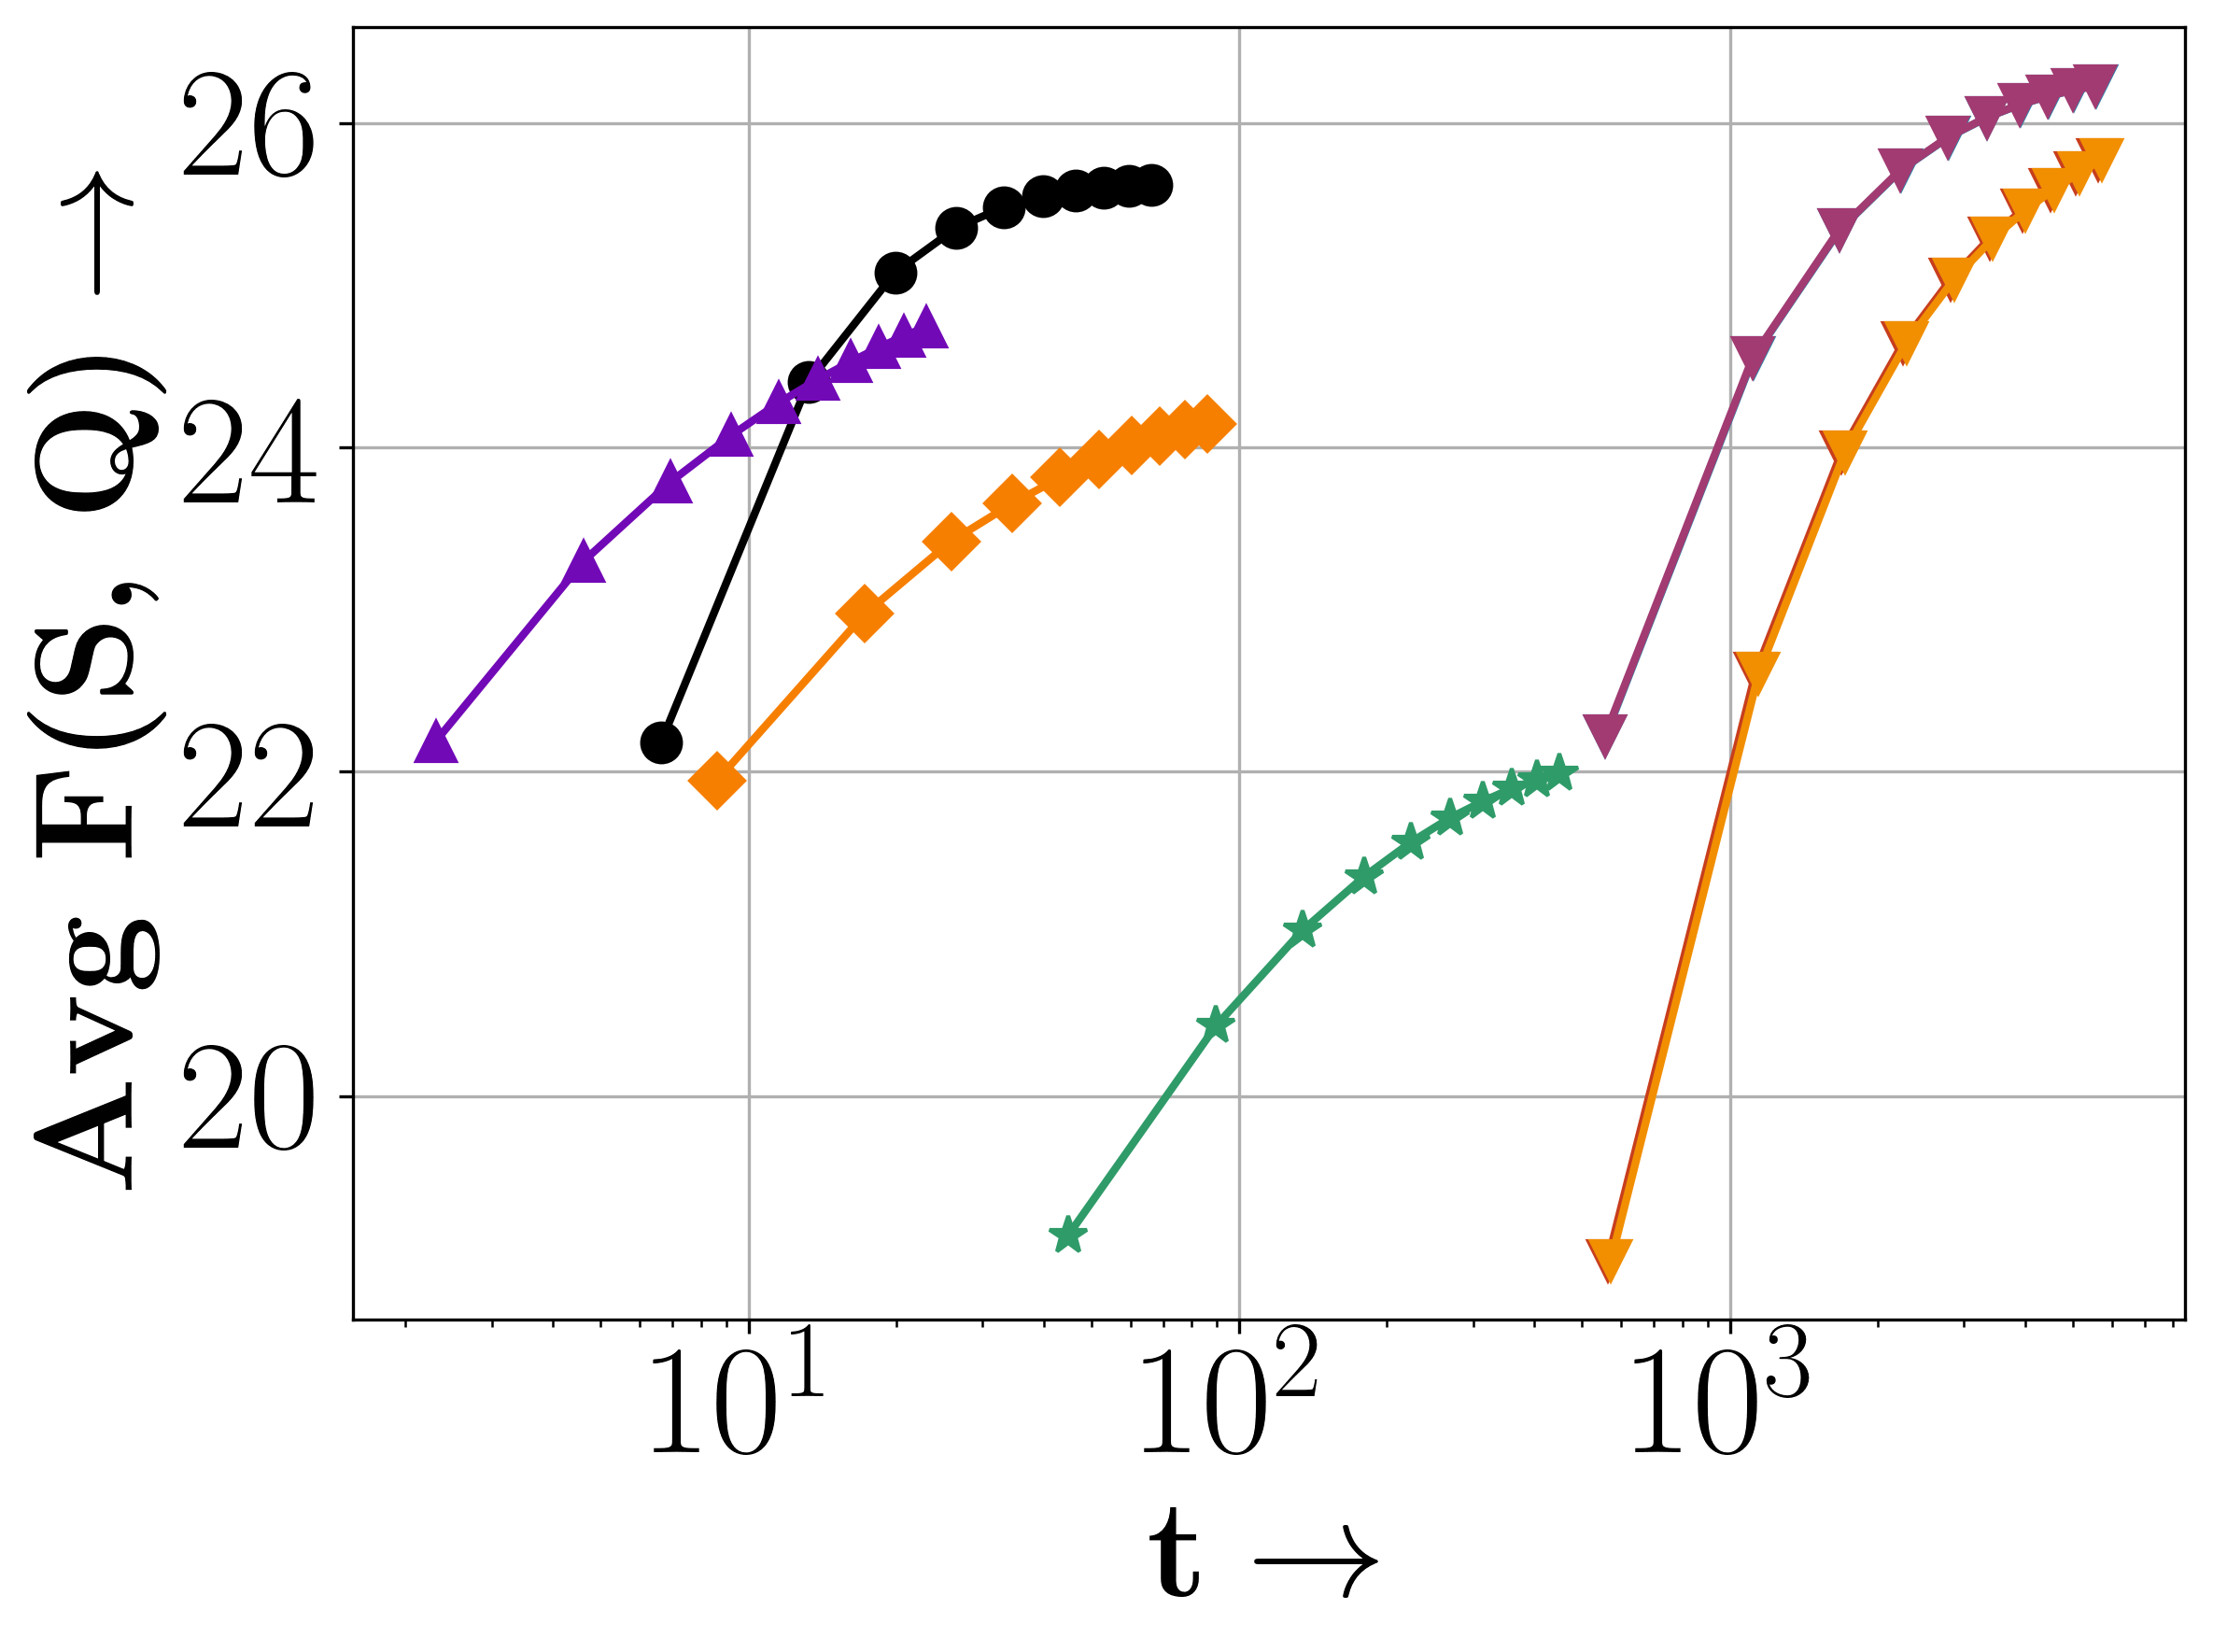

In [115]:
plot_paper("pooled", dms, y_label=True)

Method: ColBERT bypass - 1, Time: 4.0838, Score: [21.884695053100586, 23.849123001098633, 24.44626235961914, 24.68818473815918, 24.80754852294922, 24.871965408325195, 24.905765533447266, 24.924226760864258, 24.93465232849121, 24.94054412841797]
Method: submodlib ltl 0.5, Time: 400.16, Score: [19.384090423583984, 22.46748924255371, 23.57585906982422, 24.116962432861328, 24.44021224975586, 24.64595603942871, 24.79187774658203, 24.89845848083496, 24.98358917236328, 25.04934310913086]
Method: exact greedy, Time: 380.31, Score: [21.93305778503418, 23.99359703063965, 24.6750545501709, 24.99469757080078, 25.16806411743164, 25.27025604248047, 25.335426330566406, 25.379371643066406, 25.41006851196289, 25.43199348449707]
Method: MUVERA iid, Time: 1.5438999999999998, Score: [18.953569412231445, 20.07395362854004, 20.607154846191406, 20.8906192779541, 21.08280372619629, 21.22604751586914, 21.31749725341797, 21.40045166015625, 21.471914291381836, 21.527963638305664]
Method: submodlib lazy, Time: 37

<Figure size 1920x1440 with 0 Axes>

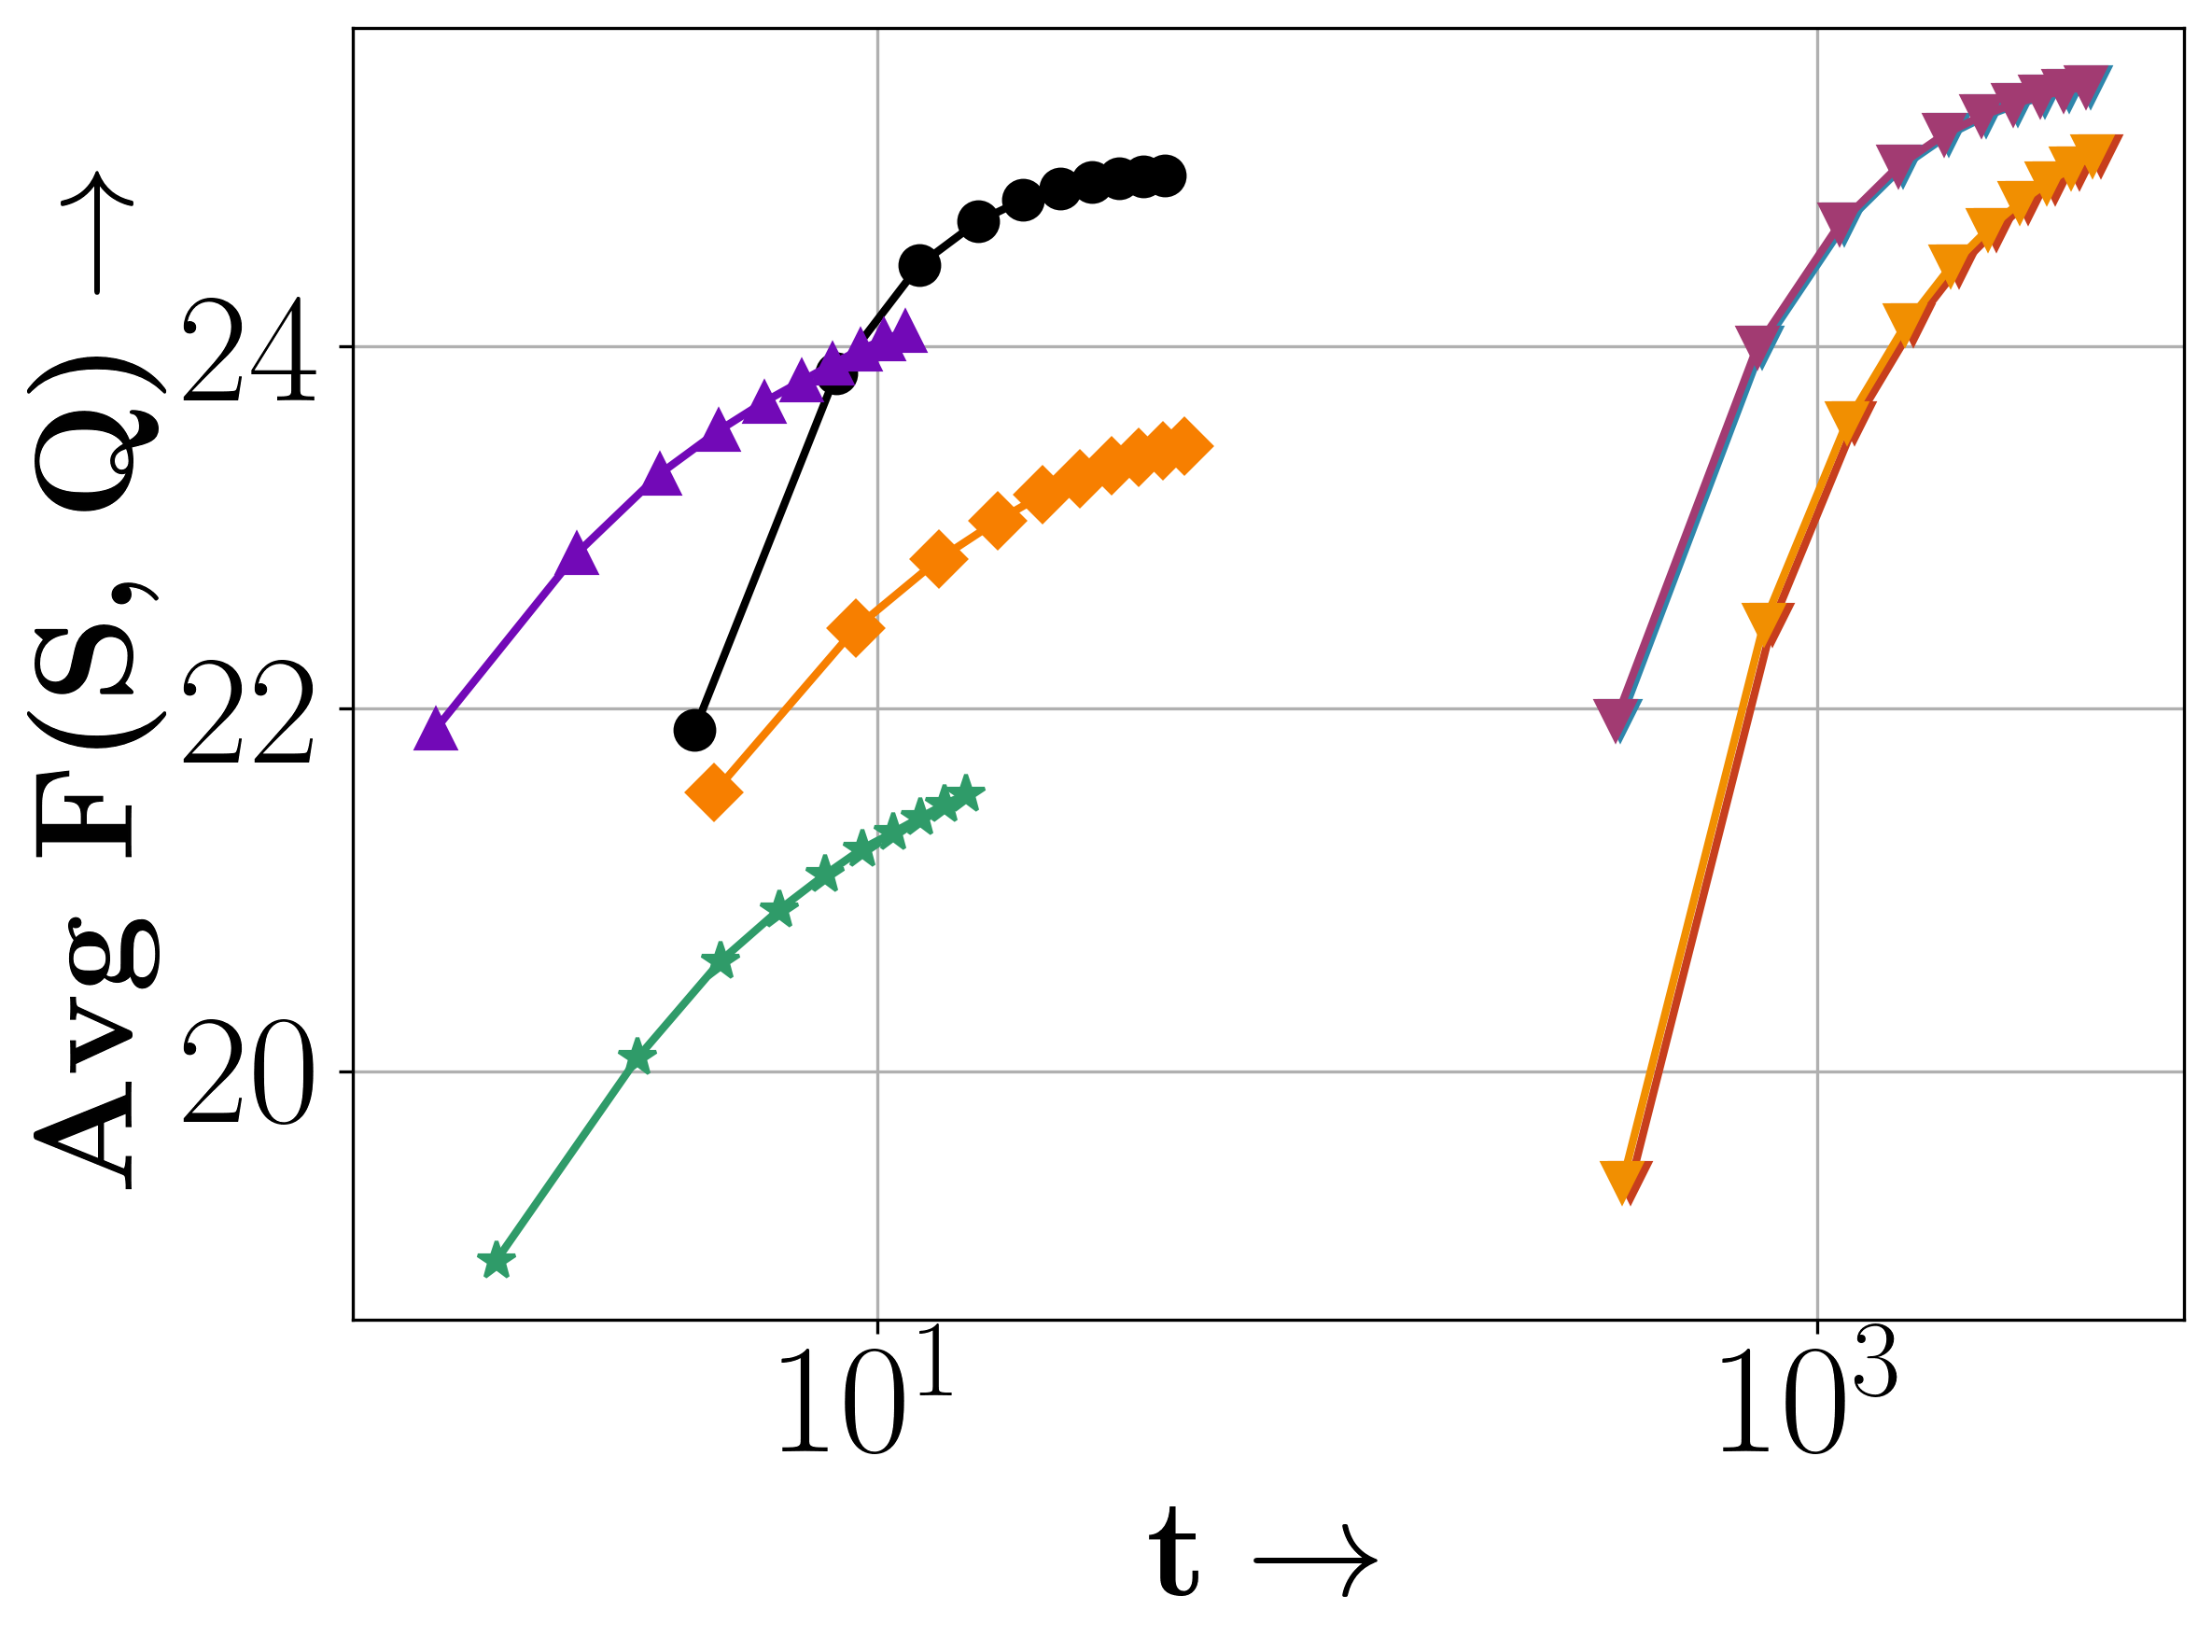

In [116]:
plot_paper("science", dms, y_label=True)

Method: ColBERT bypass - 1, Time: 1.1641, Score: [22.387441635131836, 24.49960708618164, 25.165668487548828, 25.445789337158203, 25.575258255004883, 25.6447811126709, 25.68406105041504, 25.705015182495117, 25.717374801635742, 25.72515869140625]
Method: submodlib ltl 0.5, Time: 208.34, Score: [18.699180603027344, 22.263202667236328, 23.7067928314209, 24.431394577026367, 24.84684944152832, 25.12456703186035, 25.331016540527344, 25.479890823364258, 25.594215393066406, 25.680530548095703]
Method: exact greedy, Time: 195.47, Score: [22.417198181152344, 24.61825180053711, 25.378461837768555, 25.72907257080078, 25.91632652282715, 26.029508590698242, 26.100866317749023, 26.148847579956055, 26.181747436523438, 26.204679489135742]
Method: MUVERA iid, Time: 1.242, Score: [19.610034942626953, 20.79461097717285, 21.361928939819336, 21.683725357055664, 21.872724533081055, 22.006031036376953, 22.096099853515625, 22.15630531311035, 22.19383430480957, 22.217748641967773]
Method: submodlib lazy, Time: 1

<Figure size 1920x1440 with 0 Axes>

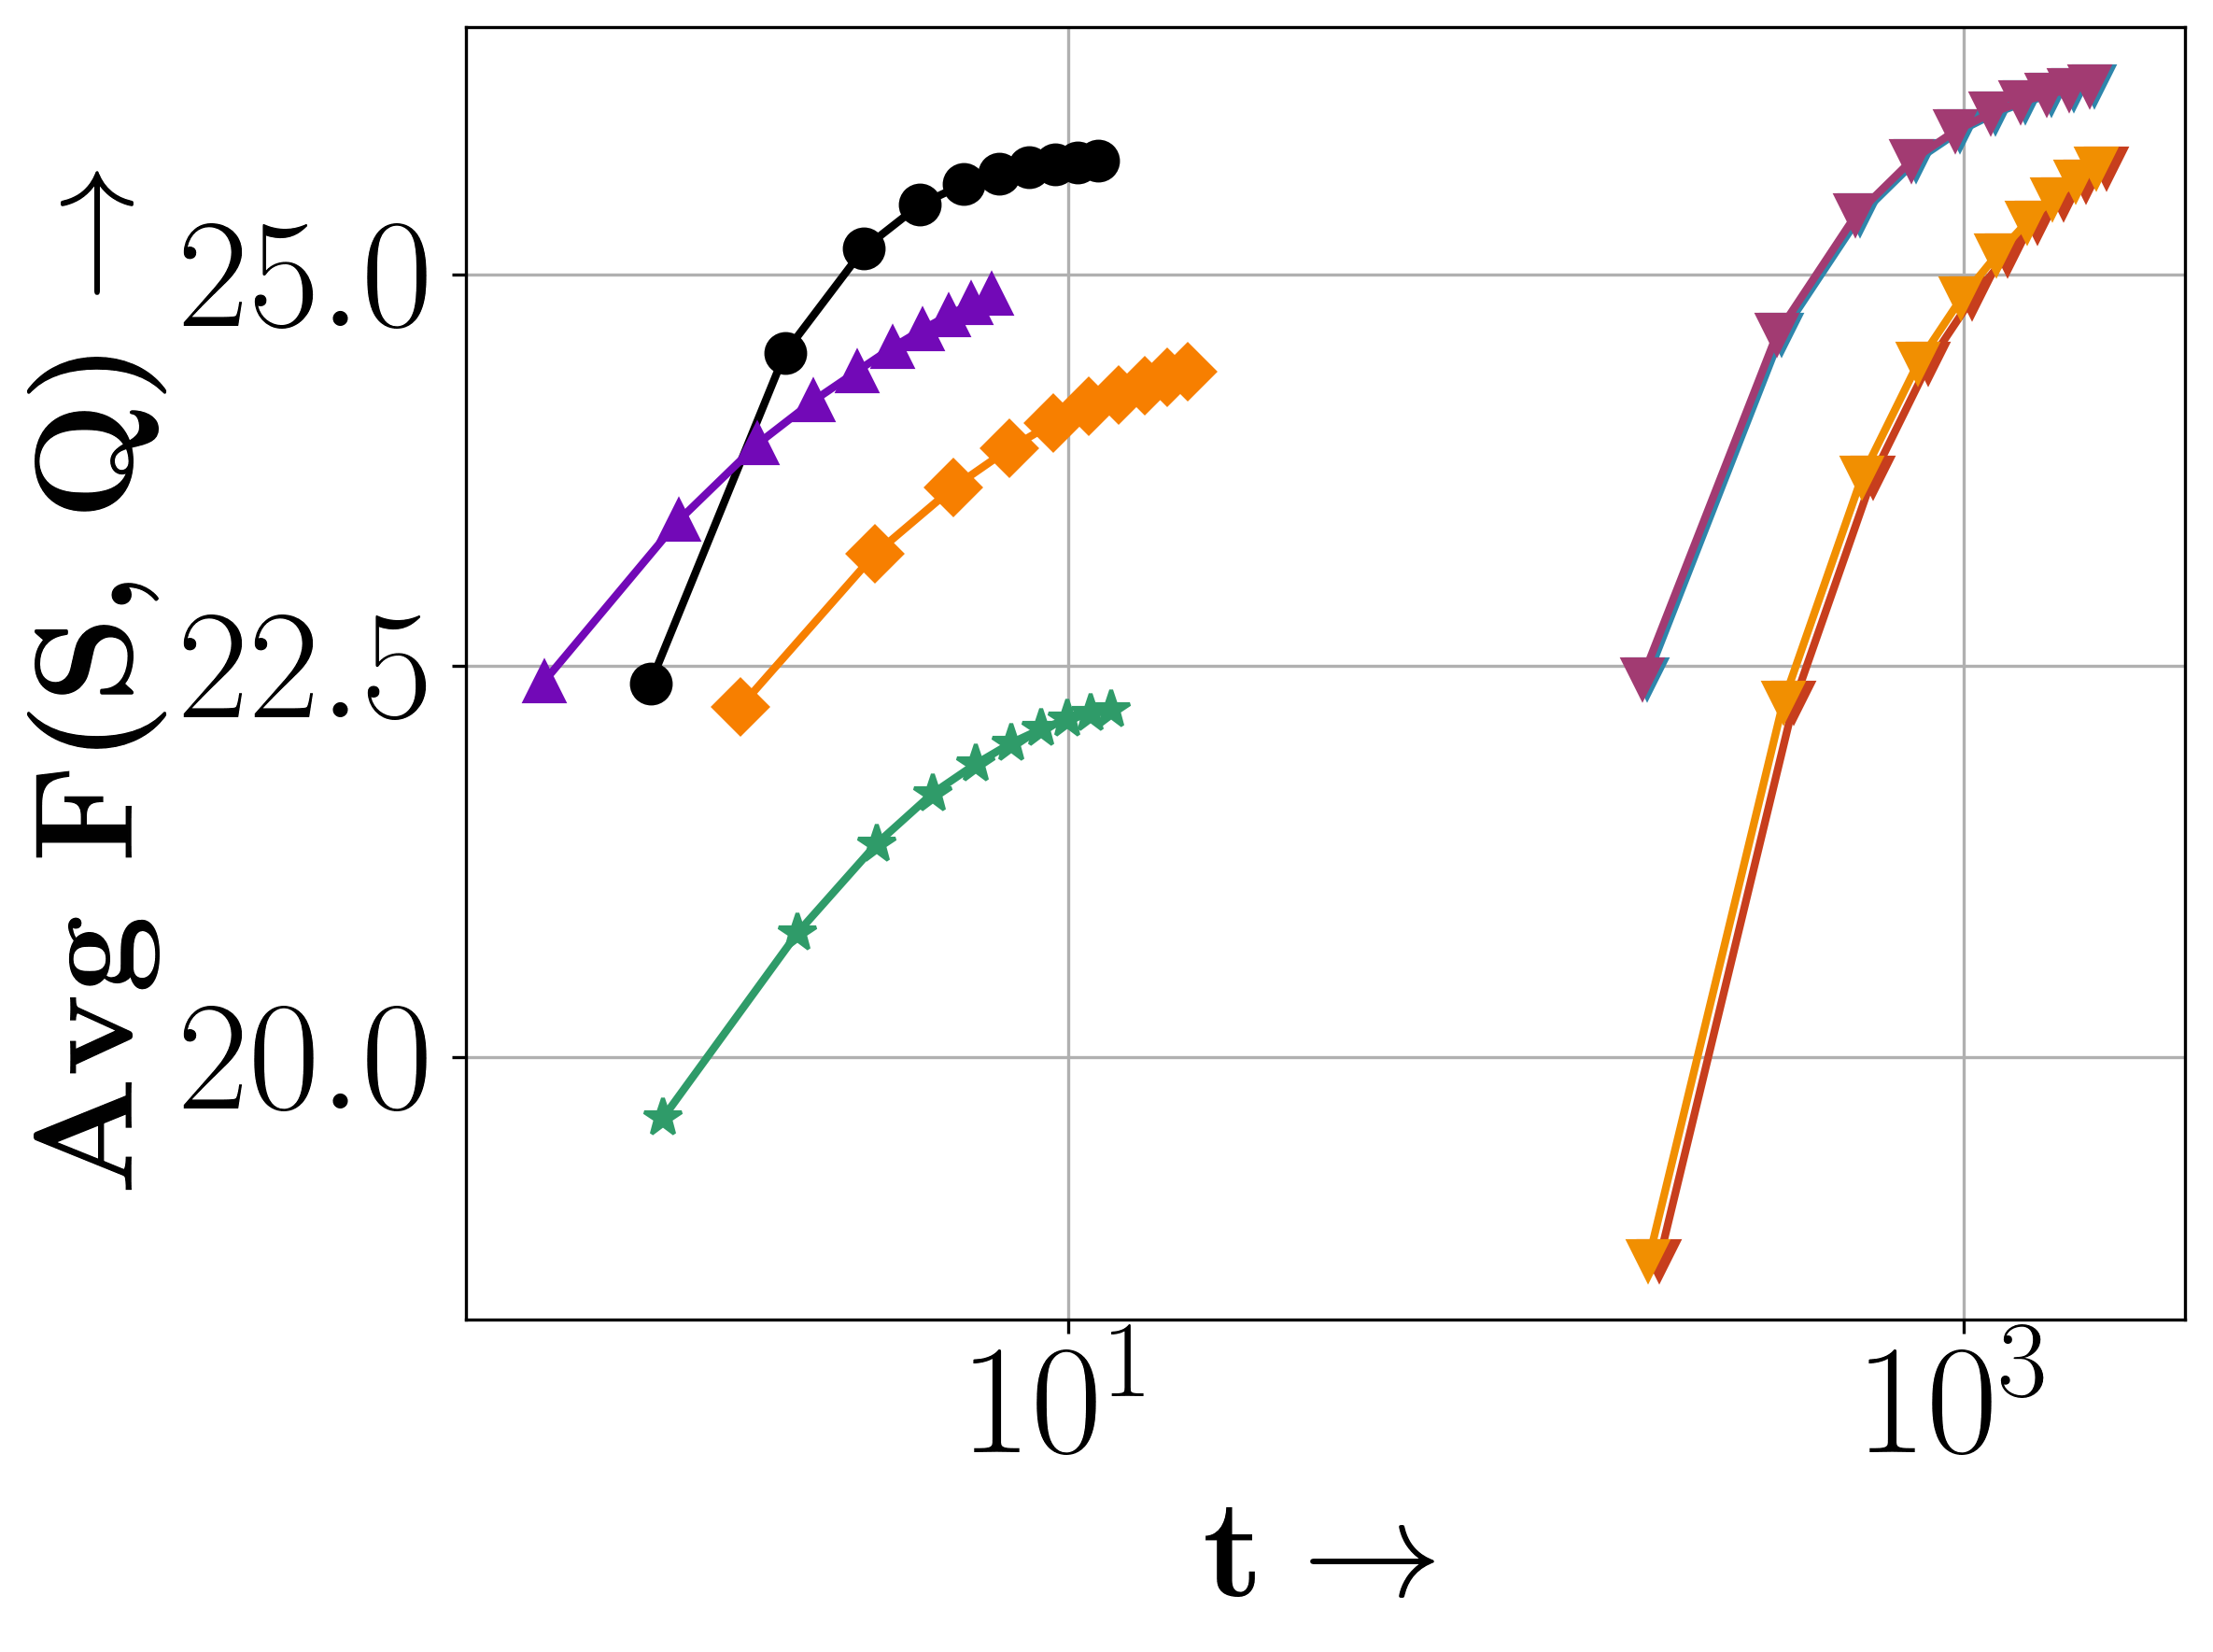

In [117]:
plot_paper("writing", dms, y_label=True)

Method: ColBERT bypass - 1, Time: 3.0747000000000004, Score: [22.84028434753418, 24.938852310180664, 25.58439826965332, 25.857093811035156, 25.98836326599121, 26.05767059326172, 26.09765625, 26.120773315429688, 26.13334083557129, 26.14117431640625]
Method: submodlib ltl 0.5, Time: 209.69, Score: [19.825626373291016, 23.28840446472168, 24.53520393371582, 25.120956420898438, 25.47295570373535, 25.706335067749023, 25.868274688720703, 25.98969841003418, 26.083574295043945, 26.15794563293457]
Method: exact greedy, Time: 188.65, Score: [22.860383987426758, 25.021953582763672, 25.74329948425293, 26.089941024780273, 26.284040451049805, 26.400897979736328, 26.476882934570312, 26.527620315551758, 26.56273078918457, 26.587892532348633]
Method: MUVERA iid, Time: 1.7533, Score: [20.12441062927246, 21.473461151123047, 22.09771156311035, 22.47374725341797, 22.720308303833008, 22.87164878845215, 22.997314453125, 23.08201026916504, 23.14640235900879, 23.19383430480957]
Method: submodlib lazy, Time: 202

<Figure size 1920x1440 with 0 Axes>

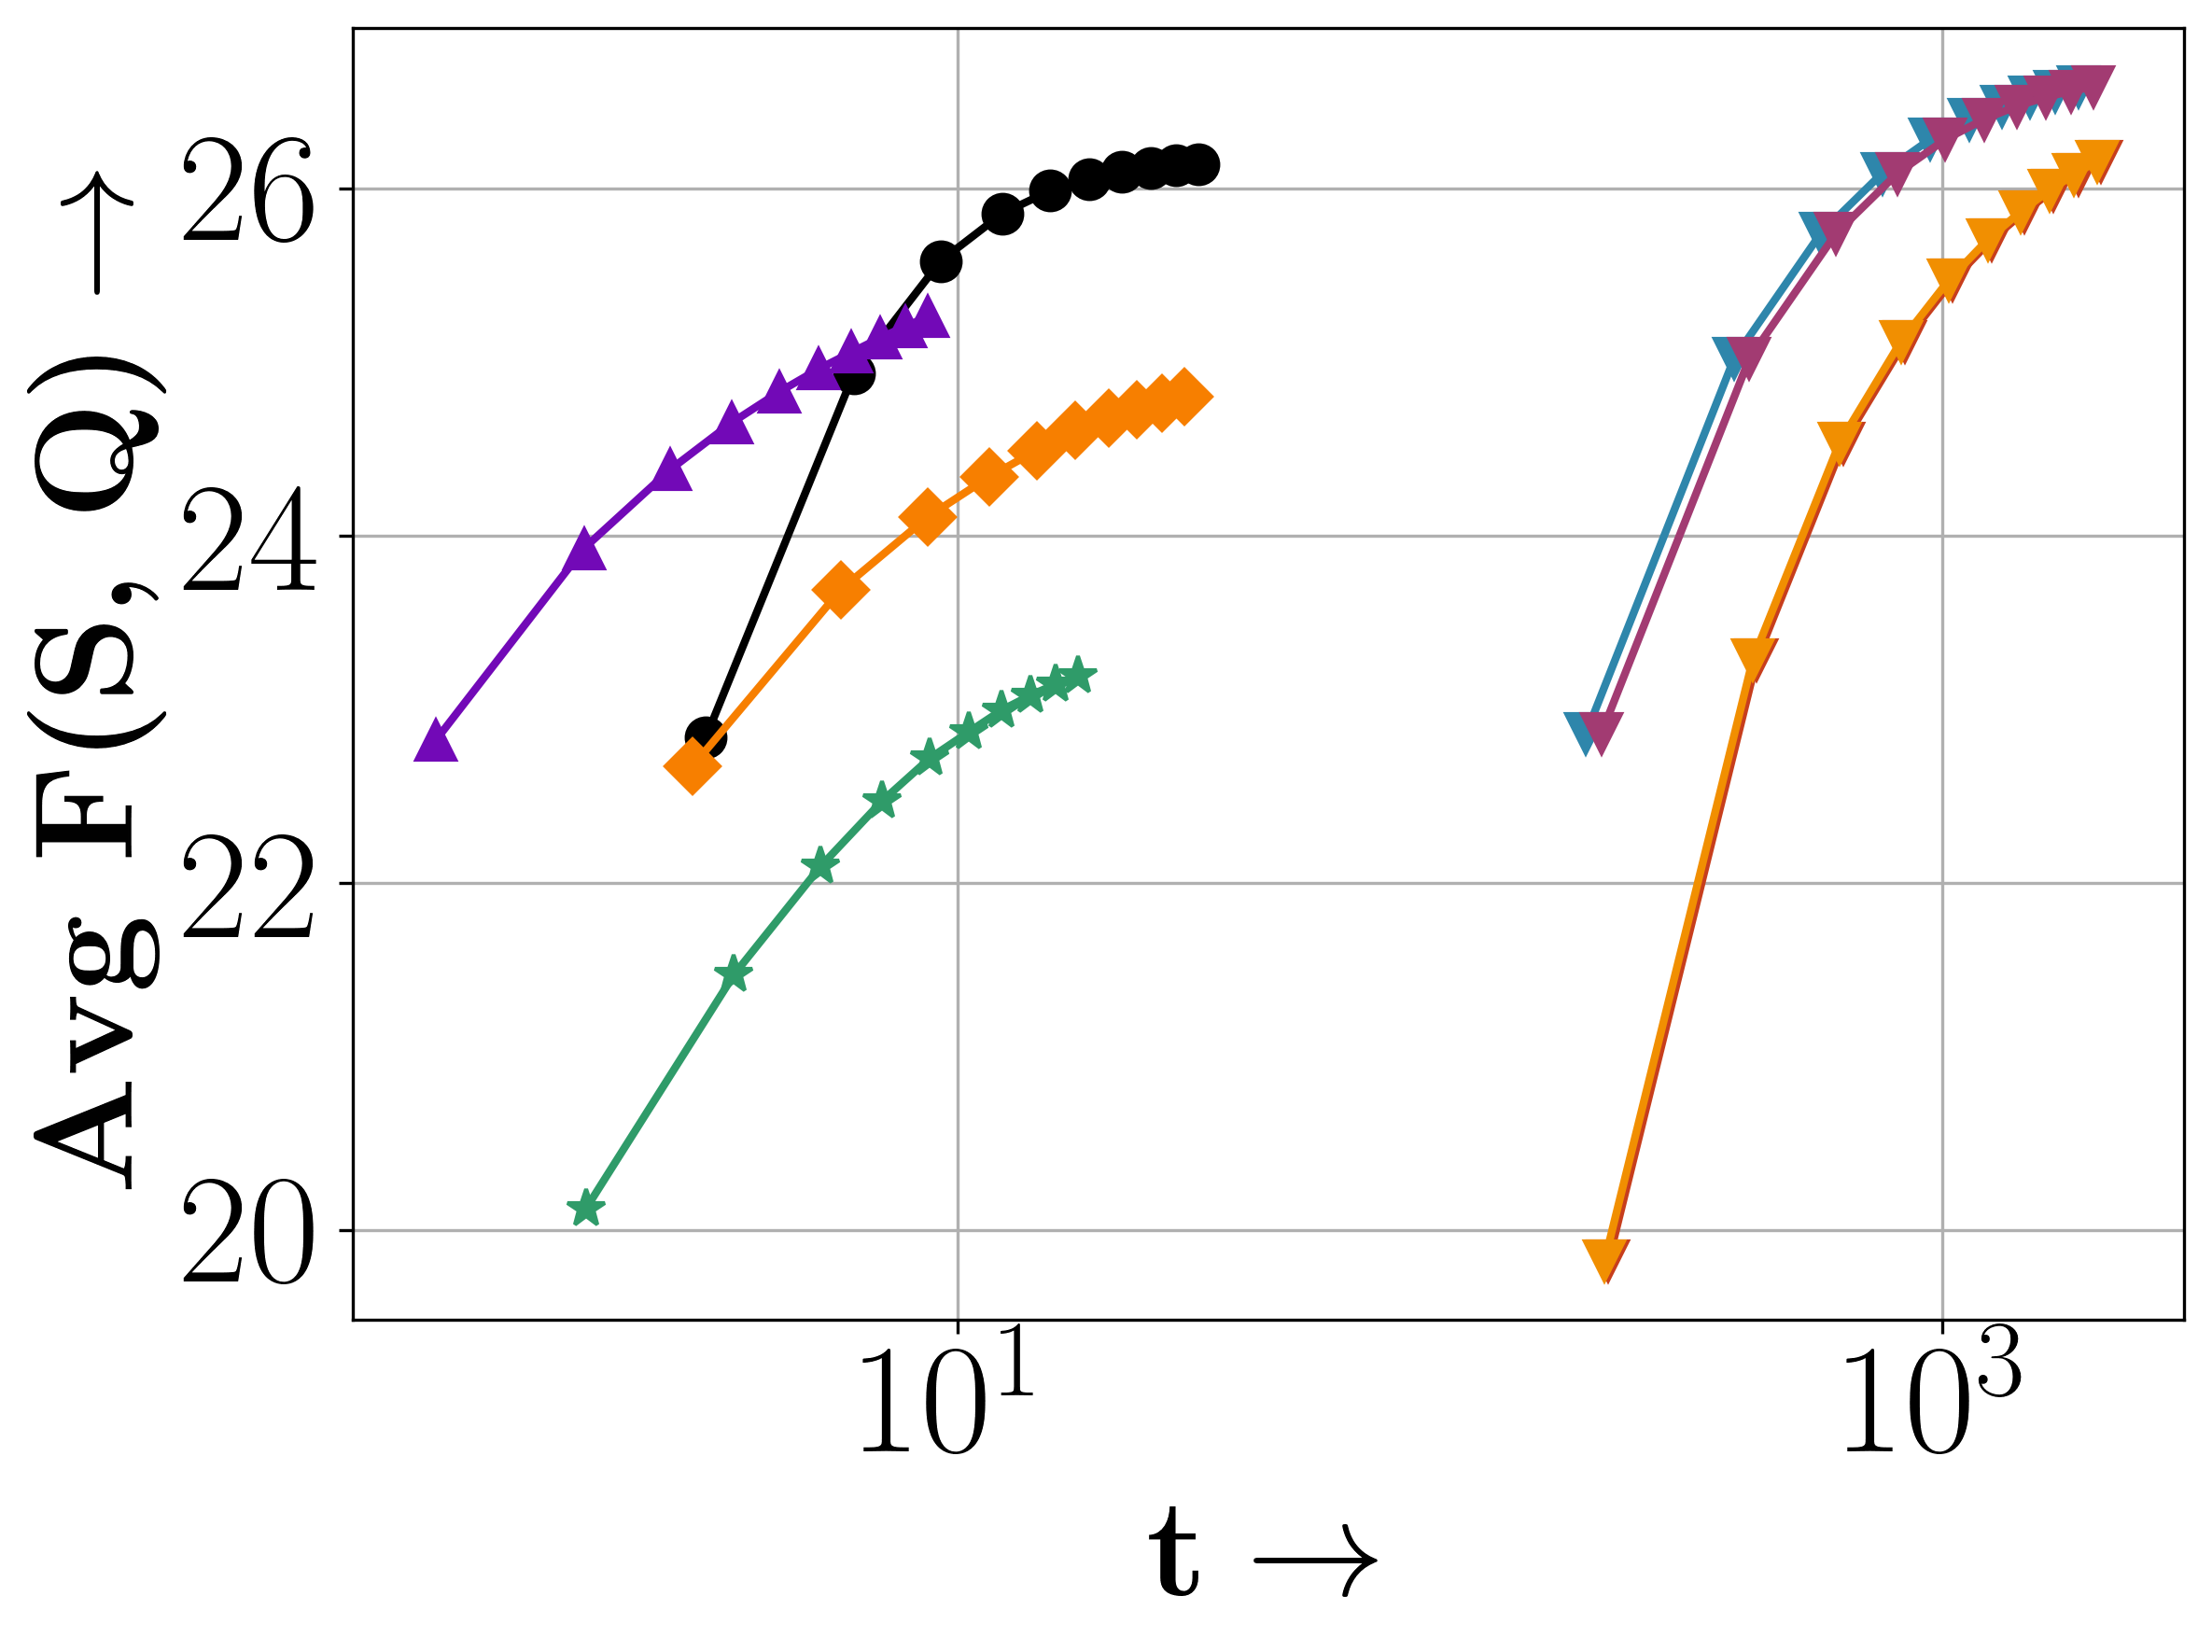

In [118]:
plot_paper("technology", dms, y_label=True)